# Carbon Emissions Analysis

## What This Notebook Is About

This notebook uses **data visualisation** to explore global carbon emissions across two complementary datasets. The aim is to show *who* is emitting and *how the mix has changed over time*.

---

### The Two Datasets

**1. Global Carbon Budget 2023** (Part 1)
- Source: Global Carbon Project (https://globalcarbonbudgetdata.org/)
- Coverage: Global total CO₂ emissions from fossil fuels, 1850–present
- Breakdown: Coal, Oil, Gas, Cement, Flaring, Other
- Unit: Originally in MtC/yr (million tonnes of **carbon**); we convert to MtCO₂/yr

**2. Carbon Majors** (Part 2)
- Source: Carbon Majors (https://carbonmajors.org/)
- Coverage: 122 of the world's largest fossil fuel producers
- Breakdown: Oil & NGL, Natural Gas, Coal, Cement
- Unit: MtCO₂e/yr (million tonnes of CO₂ equivalent)

---

### Unit Conversion: Carbon → CO₂

The Global Carbon Budget reports in **carbon mass** (MtC). To convert to **CO₂ mass** (MtCO₂), multiply by the ratio of molecular weights:

`CO₂ mass = Carbon mass × (44 / 12) = Carbon mass × 3.664`

Why? A CO₂ molecule has one carbon (12 g/mol) and two oxygens (2 × 16 = 32 g/mol) → total 44 g/mol. The "extra" mass is just the attached oxygen atoms.

---

### Visualisation Types Used

| Chart | What it shows |
|---|---|
| **Stacked bar chart** | How total emissions have grown over time, split by source |
| **100% stacked bar chart** | How the *share* of each source has changed over time |
| **Treemap** | Relative size of 122 producers; each rectangle = one company |

---

### What You Will Learn

| Concept | Where |
|---|---|
| Downloading files with `requests` + writing to `tempfile` | Part 1 setup |
| Reading Excel files with `pd.read_excel()` | Part 1 |
| Cleaning column names with regex (`re.sub`) | Part 1 |
| Reshaping data with `.melt()`: wide → long | Part 1 |
| `.assign()` for unit conversion and derived columns | Part 1 |
| `pd.Categorical` for custom ordering in plots | Parts 1 & 2 |
| Stacked bar charts with `.pivot()` + `.plot.bar(stacked=True)` | Parts 1 & 2 |
| Treemaps with the `squarify` library | Part 2 |

---

### Libraries Used
- **`requests`** — download files from URLs
- **`tempfile`** — temporary file storage (auto-deleted)
- **`pandas`** — data wrangling: read_excel, melt, groupby, assign
- **`re`** — regex for cleaning column names
- **`seaborn`** + **`matplotlib`** — stacked bar charts
- **`squarify`** — treemap visualisation (`pip install squarify`)

Two datasets are explored:
1. **Global Carbon Budget 2023** — total fossil CO₂ emissions by category (Global Carbon Budget)
2. **Carbon Majors** — emissions attributed to 122 of the world's largest producers

We create stacked bar charts, percentage fill charts, and a treemap.

In [1]:
# ── IMPORT LIBRARIES ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker   # for custom axis label formatters (e.g. "50%")
import requests    # to download files from URLs
import tempfile    # to create a temporary file path (auto-cleaned by the OS)
import os          # to delete the temp file when done
import re          # regular expressions for cleaning column names
import warnings
warnings.filterwarnings('ignore')   # suppress minor warnings for cleaner output

# Try to import squarify for the treemap in Part 2.
# If it's not installed, we catch the error and warn the user — rather than
# crashing the whole notebook. 'pip install squarify' to enable the treemap.
try:
    import squarify
except ImportError:
    print('squarify not found. Install with: pip install squarify')
    squarify = None   # set to None so we can check 'if squarify is not None' later

# Apply a consistent visual style across all plots in this notebook
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)   # default figure size: 14 wide × 7 tall (inches)


## Part 1 — Global Carbon Budget 2025

Download the official Excel workbook from the Global Carbon Budget website and read the 'Fossil Emissions by Category' sheet.

In [2]:
# --- Download the Excel file to a temporary location ---
#  Python uses requests + tempfile

url1 = 'https://globalcarbonbudget.org/download/2341/?tmstv=1762815901'

response = requests.get(url1, timeout=120)
response.raise_for_status()  # raise an error if the download failed

# Write to a temp file so pandas can read it as a normal path
temp_path = tempfile.mktemp(suffix='.xlsx')
with open(temp_path, 'wb') as f:
    f.write(response.content)

print(f'Downloaded to: {temp_path}')

Downloaded to: /var/folders/92/b0mp0v8546x1_h0np6ymywd80000gp/T/tmpiy3zg_nn.xlsx


In [3]:
# ── READ AND CLEAN THE EXCEL SHEET ───────────────────────────────────────────
#
# The Excel workbook has 8 rows of header/metadata before the actual data starts.
# skiprows=8 tells pandas to ignore those first 8 rows.
#
# METHOD CHAINING WITH .pipe():
# .pipe(lambda df: df.rename(...)) applies a function to the whole DataFrame
# within the method chain. It's equivalent to writing:
#   df = df.rename(...)
# but keeps everything in one readable chain.
#
# COLUMN NAME CLEANING:
# re.sub(r'\s+', '_', c.strip().lower()) does three things:
#   1. .strip()  → removes leading/trailing spaces
#   2. .lower()  → converts to lowercase ('Fossil Emissions' → 'fossil emissions')
#   3. re.sub(r'\s+', '_', ...) → replaces any whitespace with underscores
# This is equivalent to R's janitor::clean_names()

global_emissions = (
    pd.read_excel(
        temp_path,
        sheet_name='Fossil Emissions by Category',
        skiprows=8          # skip the 8 metadata rows at the top
    )
    .pipe(lambda df: df.rename(
        columns={c: re.sub(r'\s+', '_', c.strip().lower()) for c in df.columns}
        # dict comprehension: {old_name: new_name for each column}
    ))
)

print('Shape:', global_emissions.shape)
global_emissions.head()


Shape: (175, 9)


,year,fossil.emissions.excluding.carbonation,coal,oil,gas,cement.emission,flaring,other,per.capita
0,1850,0.053725,0.053725,0.0,0.0,0.0,0.0,0.0,0.000043
1,1851,0.054252,0.054252,0.0,0.0,0.0,0.0,0.0,0.000043
2,1852,0.056658,0.056658,0.0,0.0,0.0,0.0,0.0,0.000044
3,1853,0.059290,0.059290,0.0,0.0,0.0,0.0,0.0,0.000046
4,1854,0.069607,0.069607,0.0,0.0,0.0,0.0,0.0,0.000054


In [4]:
# ── RESHAPE TO LONG FORMAT AND CONVERT UNITS ─────────────────────────────────
#
# The raw data is in WIDE format: one row per year, one column per source.
# For seaborn stacked bar charts we need LONG format: one row per (year, source).
#
# BEFORE (wide):
#   year  coal  oil  gas  cement  ...
#   1850  0.05  0.0  0.0  0.0
#   1851  0.05  0.0  0.0  0.0
#
# AFTER (long):
#   year  source  carbon_emissions
#   1850  coal    0.05
#   1850  oil     0.0
#   1850  gas     0.0
#   1851  coal    0.05
#   ...
#
# We then add a co2_emissions column: carbon × 3.664 → CO₂ equivalent

# Identify which columns are the emission source categories (columns 3–8)
source_cols = global_emissions.columns[2:8].tolist()
year_col    = global_emissions.columns[0]     # first column = 'year'

global_emissions_long = (
    global_emissions
    [[year_col] + source_cols]           # keep only year + the 6 source columns
    # .melt() reshapes from wide to long:
    # id_vars   = column(s) that stay as identifiers (year)
    # var_name  = name for the new column that holds the old column names (→ 'source')
    # value_name = name for the new column that holds the values (→ 'carbon_emissions')
    .melt(
        id_vars=year_col,
        var_name='source',
        value_name='carbon_emissions'
    )
    # .assign() adds new derived columns:
    # pd.to_numeric(..., errors='coerce') converts strings to numbers; non-numeric → NaN
    .assign(
        year=lambda df: pd.to_numeric(df[year_col], errors='coerce'),
        # Unit conversion: MtC → MtCO₂ by multiplying by 44/12 ≈ 3.664
        co2_emissions=lambda df: 3.664 * pd.to_numeric(df['carbon_emissions'], errors='coerce')
    )
    .dropna(subset=['year', 'co2_emissions'])   # remove rows where conversion failed
    .rename(columns={year_col: 'year_raw'})
)

print('Long format shape:', global_emissions_long.shape)
global_emissions_long.head()


Long format shape: (1050, 4)


,year_raw,source,carbon_emissions,co2_emissions
0,1850,coal,0.053725,0.196848
1,1851,coal,0.054252,0.198779
2,1852,coal,0.056658,0.207595
3,1853,coal,0.059290,0.217237
4,1854,coal,0.069607,0.255039


In [5]:
# --- Order 'source' factor by total emissions (descending) ---
# Here we reorder using pandas Categorical

source_order = (
    global_emissions_long
    .groupby('source')['co2_emissions']
    .sum()
    .sort_values()           # ascending so lowest is first
    .index.tolist()
)

global_emissions_long['source'] = pd.Categorical(
    global_emissions_long['source'],
    categories=source_order,
    ordered=True
)

# Custom colour palette matching the R script
my_colours = ['#b2182b', '#ef8a62', '#c7eae5', '#e0e0e0', '#d8b365', '#8c510a']
colour_map  = dict(zip(source_order, my_colours[:len(source_order)]))

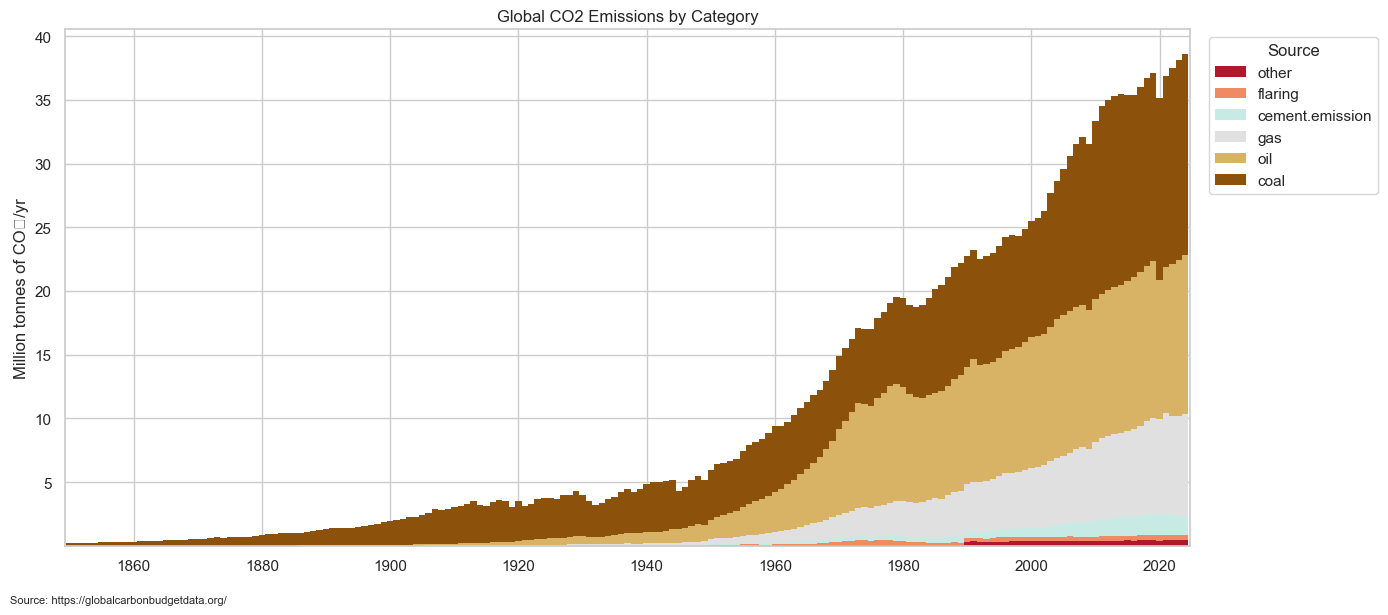

In [7]:
# ── STACKED BAR CHART: absolute CO₂ emissions by year ───────────────────────
#
# To make a stacked bar chart in matplotlib, we need data in PIVOT TABLE format:
#   rows = years, columns = sources, values = emissions
# This is the opposite of the long format we just created for seaborn.
#
# The workflow:
#   long → .groupby(['year', 'source']).sum() → .unstack('source') → PIVOT TABLE
#
# .groupby(['year_raw', 'source'], observed=True)['co2_emissions'].sum()
#   → one value per (year, source) combination
#
# .unstack('source')
#   → rotates 'source' from a row index into column headers
#   → result: rows = years, columns = coal / oil / gas / cement / etc.
#
# .fillna(0)
#   → replace NaN with 0 (some early years had no oil/gas emissions)

pivot_abs = (
    global_emissions_long
    .groupby(['year_raw', 'source'], observed=True)['co2_emissions']
    .sum()
    .unstack('source')       # wide format: sources become columns
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(14, 6))

# .plot.bar(stacked=True): draws a stacked bar chart where each bar segment
# corresponds to one column (source). Bars are stacked vertically.
# color=[...]: we specify the colour for each source from our custom palette.
# width=1.0: bars touch each other (no gaps). For 175 years of data, gaps would
#            make the chart look very sparse.
pivot_abs.plot.bar(
    stacked=True,
    ax=ax,
    color=[colour_map.get(c, 'grey') for c in pivot_abs.columns],
    width=1.0,       # width=1 removes gaps between bars
    linewidth=0      # no bar borders (cleaner look)
)
ax.set_xlabel('')
ax.set_ylabel('Million tonnes of CO₂/yr')
ax.set_title('Global CO2 Emissions by Category')
ax.legend(title='Source', bbox_to_anchor=(1.01, 1), loc='upper left')

# Show x-tick labels every 20 years to avoid crowding the axis.
# enumerate(pivot_abs.index) gives (position, year) pairs.
tick_pos = [i for i, y in enumerate(pivot_abs.index) if int(y) % 20 == 0]
ax.set_xticks(tick_pos)
ax.set_xticklabels([int(pivot_abs.index[i]) for i in tick_pos], rotation=0)

plt.figtext(0.01, -0.02, 'Source: https://globalcarbonbudgetdata.org/', fontsize=8)
plt.tight_layout()
plt.show()


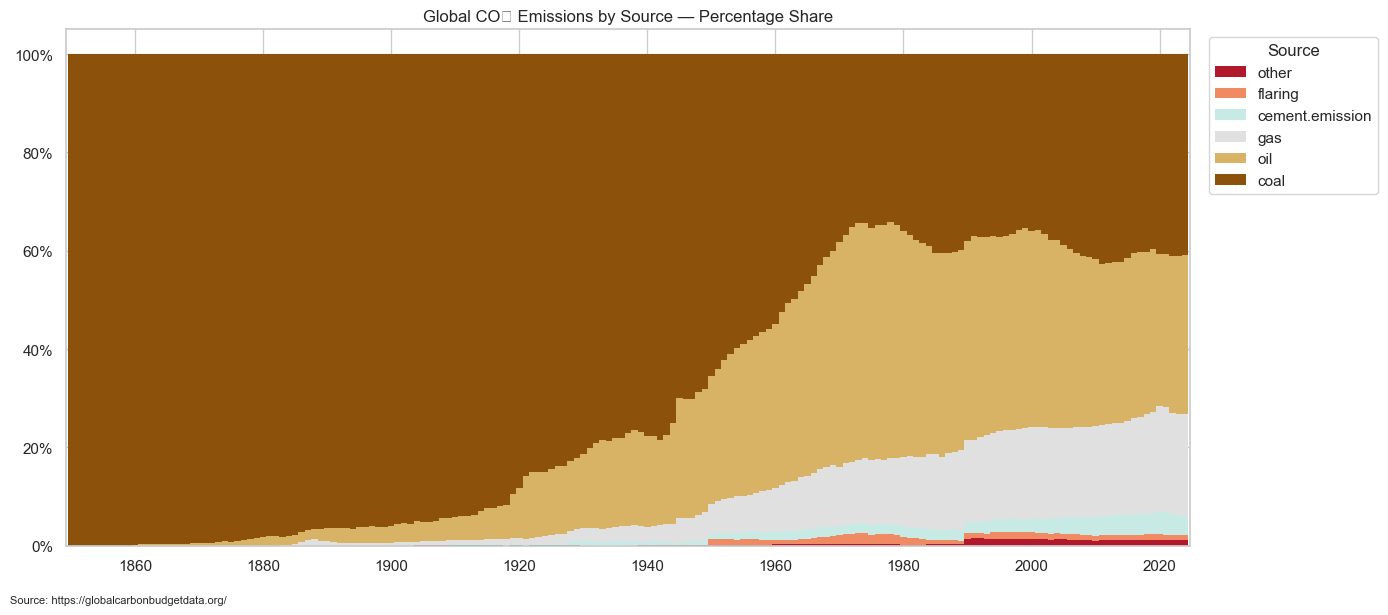

In [ ]:
# ── 100% STACKED BAR CHART: proportional share by source ─────────────────────
#
# The absolute chart shows TOTAL emissions growing over time.
# This chart asks a different question: HOW HAS THE MIX CHANGED?
# e.g. Was coal's share always dominant? When did oil/gas become important?
#
# To normalise each year to 100%:
#   pivot_pct = pivot_abs.div(pivot_abs.sum(axis=1), axis=0)
#
# .sum(axis=1) → sum across columns for each row = total emissions per year
# .div(..., axis=0) → divide each row by its own total
# Result: every row sums to 1.0 (= 100%)

pivot_pct = pivot_abs.div(pivot_abs.sum(axis=1), axis=0)   # normalise each year to 100%

fig, ax = plt.subplots(figsize=(14, 6))
pivot_pct.plot.bar(
    stacked=True,
    ax=ax,
    color=[colour_map.get(c, 'grey') for c in pivot_pct.columns],
    width=1.0,
    linewidth=0
)
# PercentFormatter(xmax=1, decimals=0) formats y-axis values:
#   0.5 → "50%"  |  1.0 → "100%"
#   xmax=1 means the raw values are fractions (0 to 1), not 0 to 100
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title('Global CO2 Emissions by Source — Percentage Share')
ax.legend(title='Source', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticks(tick_pos)
ax.set_xticklabels([int(pivot_abs.index[i]) for i in tick_pos], rotation=0)
plt.figtext(0.01, -0.02, 'Source: https://globalcarbonbudgetdata.org/', fontsize=8)
plt.tight_layout()
plt.show()


## Part 2 — Carbon Majors Dataset

Emissions attributed to 122 of the world's largest coal, oil, gas, and cement producers (1854–present).

In [9]:
# --- Download Carbon Majors data directly from their website ---
cm_url = 'https://carbonmajors.org/evoke/391/get_cm_file?type=Basic&file=emissions_medium_granularity.csv'

emissions = pd.read_csv(cm_url)
print('Carbon Majors data shape:', emissions.shape)
emissions.head()

Carbon Majors data shape: (14894, 8)


,year,parent_entity,parent_type,lei,commodity,production_value,production_unit,total_emissions_MtCO2e
0,1962,Abu Dhabi National Oil Company,State-owned Entity,5493009O1JMLWDLTIC26,Oil & NGL,0.91250,Million bbl/yr,0.363885
1,1962,Abu Dhabi National Oil Company,State-owned Entity,5493009O1JMLWDLTIC26,Natural Gas,1.84325,Bcf/yr,0.134355
2,1963,Abu Dhabi National Oil Company,State-owned Entity,5493009O1JMLWDLTIC26,Oil & NGL,1.82500,Million bbl/yr,0.727770
3,1963,Abu Dhabi National Oil Company,State-owned Entity,5493009O1JMLWDLTIC26,Natural Gas,4.42380,Bcf/yr,0.322453
4,1964,Abu Dhabi National Oil Company,State-owned Entity,5493009O1JMLWDLTIC26,Oil & NGL,7.30000,Million bbl/yr,2.911079


In [10]:
# --- Simplify commodity names: collapse Coal sub-types into 'Coal' ---
# Python equivalent: use regex replace on the commodity column

emissions = (
    emissions
    .assign(
        new_commodity=lambda df: df['commodity'].str.replace(
            r'.*(Coal)$', 'Coal', regex=True
        )
    )
)

print('Distinct new_commodity values:')
print(emissions['new_commodity'].value_counts())

Distinct new_commodity values:
new_commodity
Coal           7093
Oil & NGL      3873
Natural Gas    3629
Cement          299
Name: count, dtype: int64


In [11]:
# --- Order commodities by total emissions ---
cm_levels = (
    emissions
    .groupby('new_commodity')['total_emissions_MtCO2e']
    .sum()
    .sort_values()     # ascending: smallest total first
    .index.tolist()
)

emissions['new_commodity'] = pd.Categorical(
    emissions['new_commodity'], categories=cm_levels, ordered=True
)

# 4 colour palette for 4 commodity categories
cm_colours = ['#c7eae5', '#e0e0e0', '#d8b365', '#8c510a']
cm_colour_map = dict(zip(cm_levels, cm_colours[:len(cm_levels)]))

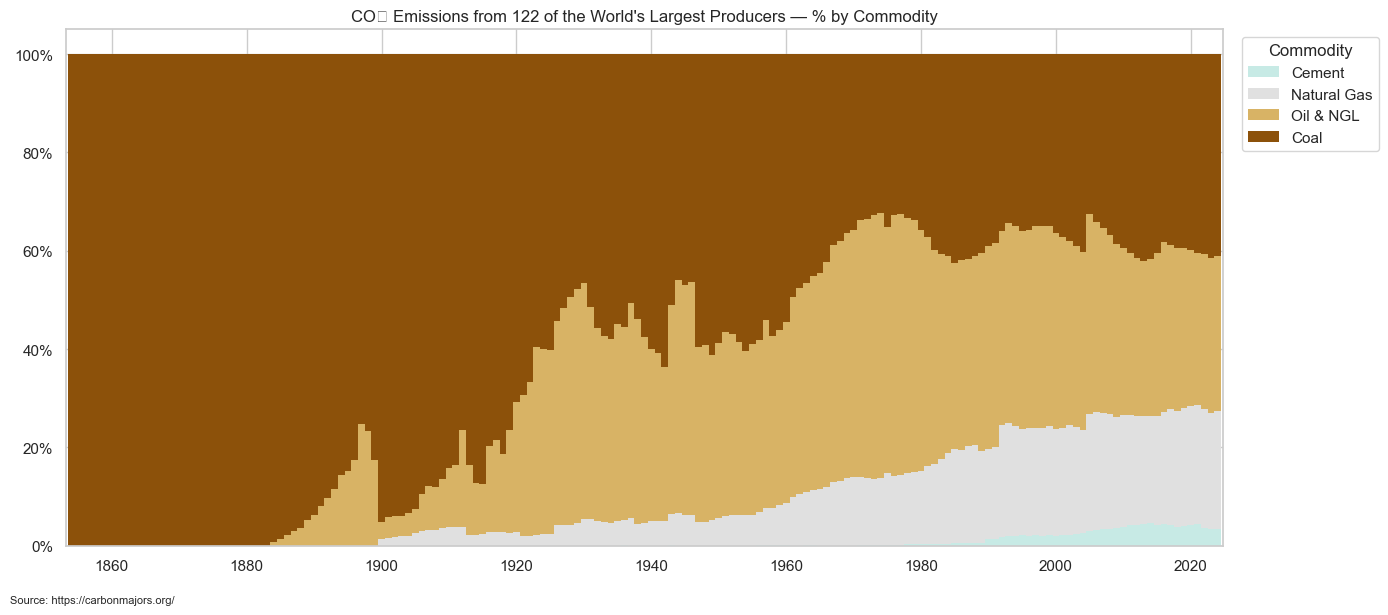

In [ ]:
# --- Percentage stacked bar: share of emissions by commodity per year ---

cm_pivot_pct = (
    emissions
    .groupby(['year', 'new_commodity'], observed=True)['total_emissions_MtCO2e']
    .sum()
    .unstack('new_commodity')
    .fillna(0)
    .pipe(lambda df: df.div(df.sum(axis=1), axis=0))   # normalise to 100% per year
)

fig, ax = plt.subplots(figsize=(14, 6))
cm_pivot_pct.plot.bar(
    stacked=True,
    ax=ax,
    color=[cm_colour_map.get(c, 'grey') for c in cm_pivot_pct.columns],
    width=1.0,
    linewidth=0
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_title("CO2 Emissions from 122 of the World's Largest Producers — % by Commodity")
ax.legend(title='Commodity', bbox_to_anchor=(1.01, 1), loc='upper left')

tick_pos_cm = [i for i, y in enumerate(cm_pivot_pct.index) if int(y) % 20 == 0]
ax.set_xticks(tick_pos_cm)
ax.set_xticklabels([int(cm_pivot_pct.index[i]) for i in tick_pos_cm], rotation=0)
plt.figtext(0.01, -0.02, 'Source: https://carbonmajors.org/', fontsize=8)
plt.tight_layout()
plt.show()

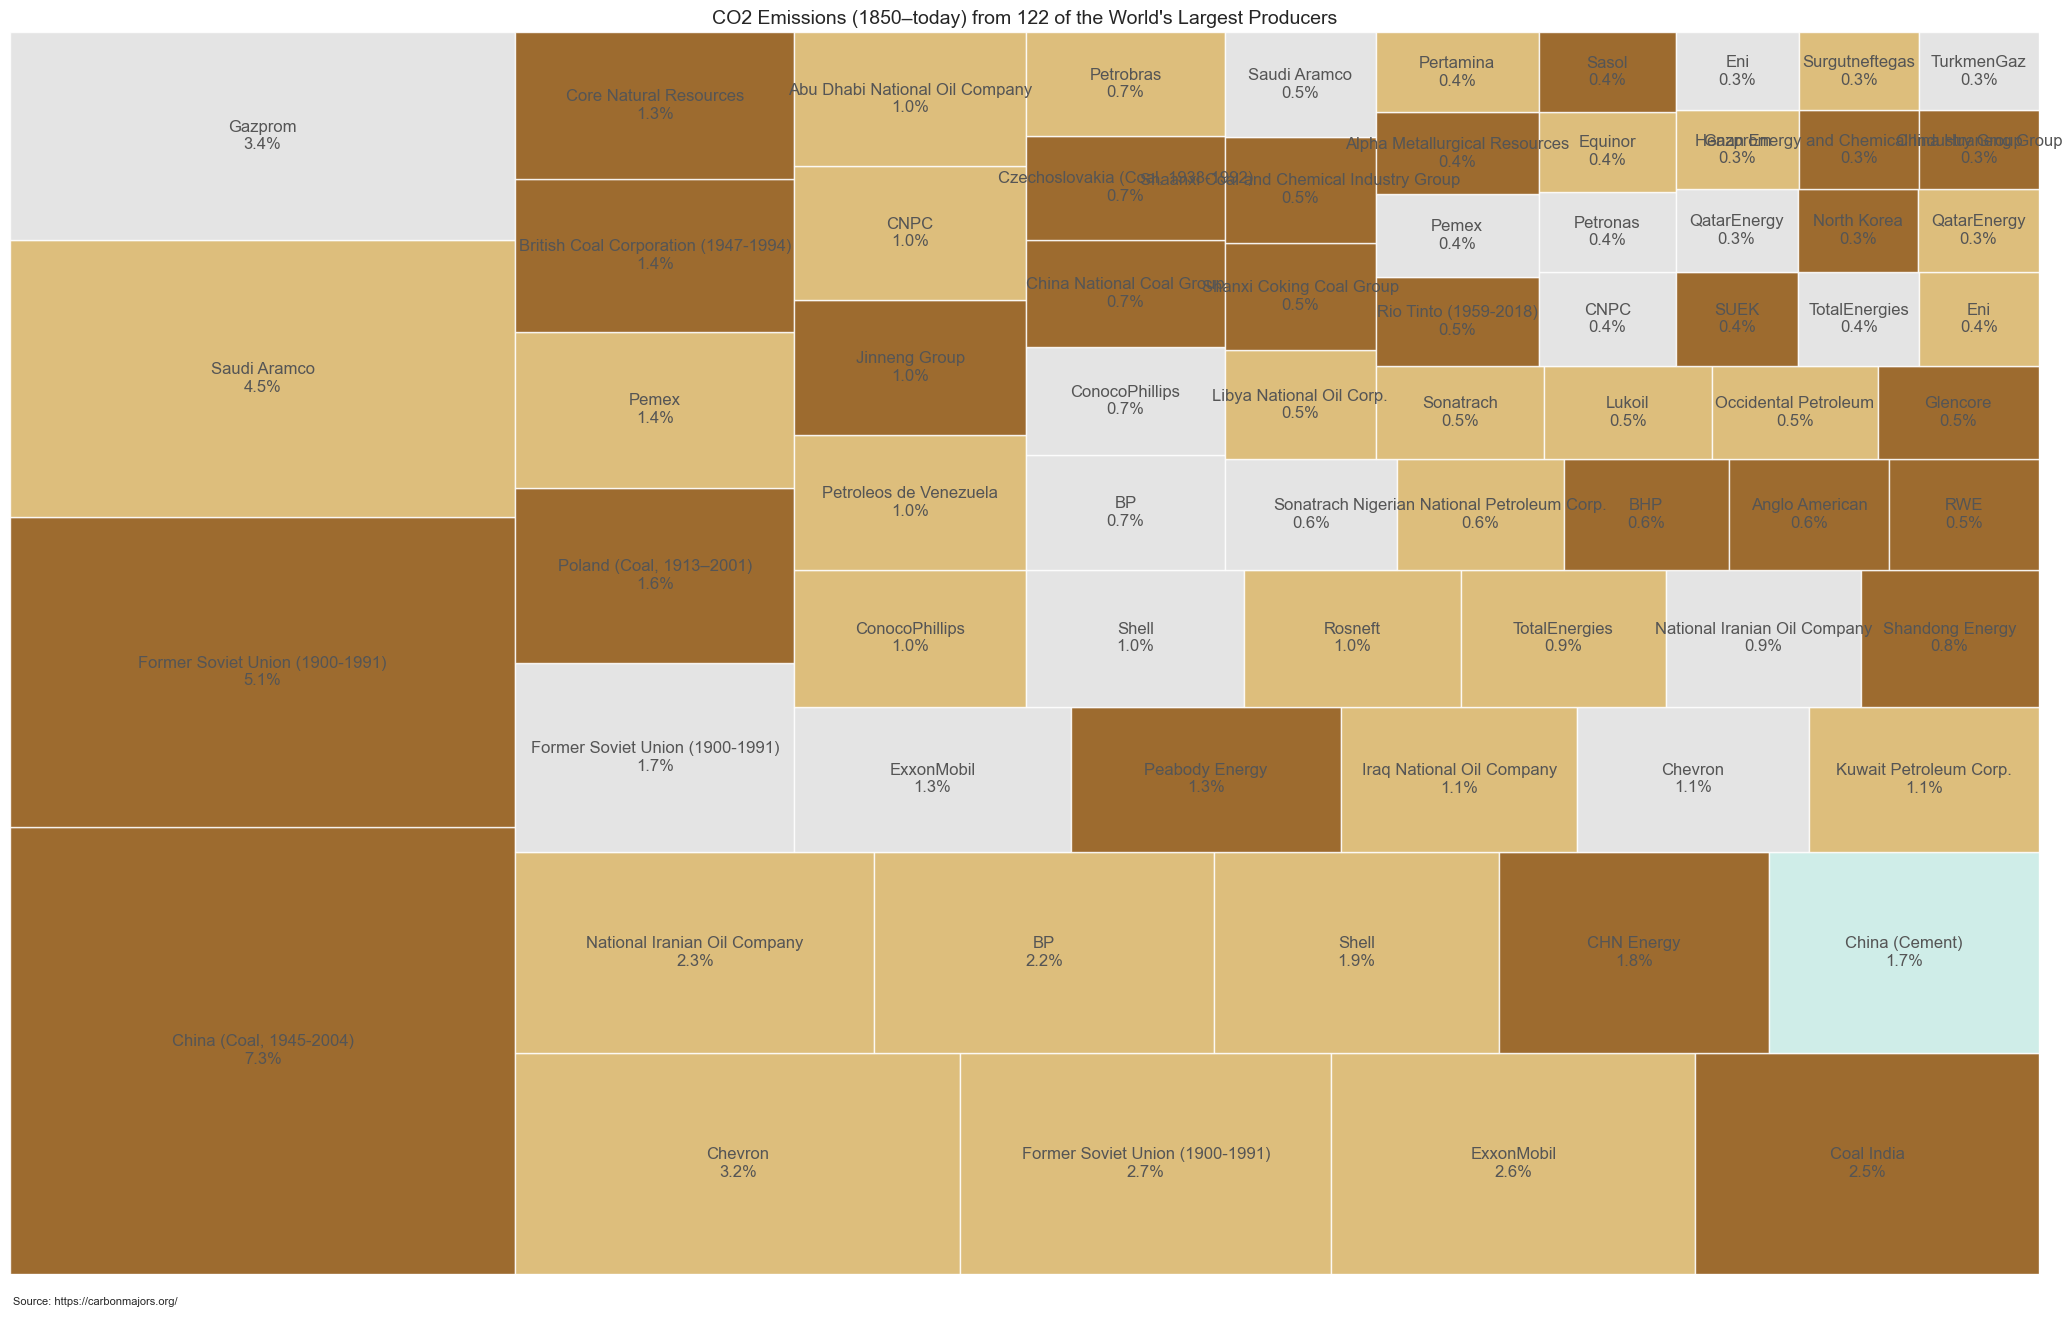

In [14]:
# --- Treemap: each rectangle = one producer entity, sized by total emissions ---

if squarify is not None:
    treemap_data = (
        emissions
        .groupby(['parent_entity', 'new_commodity'], observed=True)['total_emissions_MtCO2e']
        .sum()
        .reset_index()
        .assign(
            total=lambda df: df['total_emissions_MtCO2e'],
            percent=lambda df: df['total'] / df['total'].sum()
        )
        .query('percent > 0.003')   # <-- filter: only entities > 0.3%

        .sort_values('total', ascending=False)
    )

    # Build label: entity + % (mirrors R's paste(parent_entity, scales::percent(...)))
    treemap_data['label'] = (
        treemap_data['parent_entity'] + '\n' +
        treemap_data['percent'].map(lambda x: f'{x:.1%}')
    )

    # Assign colours based on commodity
    treemap_data['colour'] = treemap_data['new_commodity'].map(cm_colour_map)

    fig, ax = plt.subplots(figsize=(21, 13))
    squarify.plot(
        sizes=treemap_data['total'],
        label=treemap_data['label'],
        color=treemap_data['colour'],
        alpha=0.85,
        text_kwargs={'fontsize': 12, 'color': '#555555'},
        ax=ax
    )
    ax.axis('off')
    ax.set_title("CO2 Emissions (1850–today) from 122 of the World's Largest Producers",
                 fontsize=14)
    plt.figtext(0.01, -0.01, 'Source: https://carbonmajors.org/', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('Install squarify (pip install squarify) to display the treemap.')

In [15]:
# --- Cleanup temporary file ---
try:
    os.remove(temp_path)
    print('Temp Excel file removed.')
except Exception:
    pass

Temp Excel file removed.
